In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.io.ascii

1, What is the number density of Na atoms in the ground state?

In [ ]:
spec = astropy.io.ascii.read("/content/solar_spectrum.txt")

Text(0, 0.5, 'Normalized Flux')

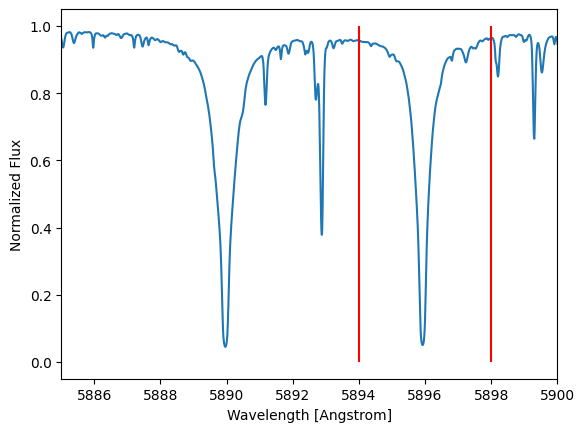

In [ ]:
plt.plot(spec["col1"], spec["col2"] / 1e4)
plt.vlines(5894, 0, 1, color="red")
plt.vlines(5898, 0, 1, color="red")
plt.xlim(5885, 5900)
plt.xlabel("Wavelength [Angstrom]")
plt.ylabel("Normalized Flux")

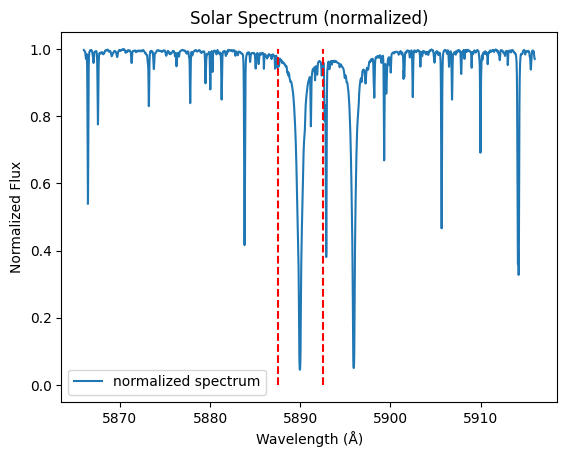

In [ ]:
#Put data from columns in lists
wavelength = spec["col1"].data
flux = spec["col2"].data

continuum = np.max(flux)

norm_flux = flux / continuum


#Plot this
plt.figure()
plt.plot(wavelength, norm_flux, label = 'normalized spectrum')
plt.vlines(5887.5, 0, 1, color = 'r', linestyle = '--')
plt.vlines(5892.5, 0, 1, color = 'r', linestyle = '--')
plt.xlabel('Wavelength (Å)')
plt.ylabel('Normalized Flux')
plt.title('Solar Spectrum (normalized)')
plt.legend()
plt.show()

In [ ]:
region_mask = np.where((wavelength >= 5887.5) & (wavelength <= 5892.5))
wave_region = wavelength[region_mask]
inc = np.median(np.diff(wavelength)[region_mask])
ew = np.sum(1e4-flux[region_mask])*inc/1e4
flux_region = norm_flux[region_mask]

print(" equivalent width =", ew)


 equivalent width = 0.8358160000182441


Now find the number of Na atoms in absorbing state based on the following curve of growth plot:

## log(W/$\lambda$) = log(0.83 / 5890) = -3.85, where W is equivalent width.
## The corresponding value on x-axis is log(Nf($\lambda/5000\overset{\circ}{A}$))$\sim$14.8.
## Rearranged, we have N = $8.24\times10^{14}$ with the unit of atoms/cm$^2$, assuming f = 0.65, where f is the oscillator strength for this transition at 5890 $\overset{\circ}{A}$.


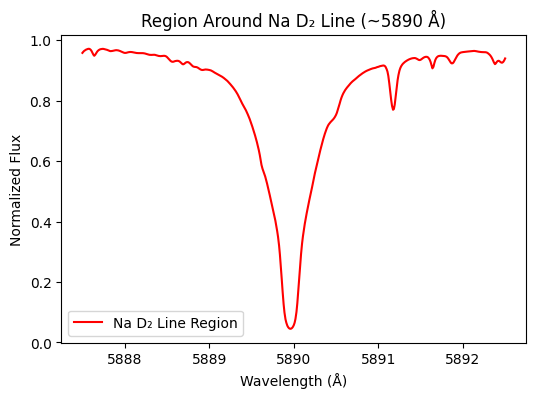

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(wave_region, flux_region, 'r-', label='Na D₂ Line Region')
plt.xlabel('Wavelength (Å)')
plt.ylabel('Normalized Flux')
plt.title('Region Around Na D₂ Line (~5890 Å)')
plt.legend()
plt.show()

2, Find the number density of Na atoms in the ground state based on the following curve of growth plot.

3, Estimate the ratio of sodium atoms in the ground state to sodium atoms in excited states using the Boltzmann equation.

In [ ]:
import astropy.units as u
import astropy.constants as ac
import numpy as np

T_solar = 5778 * u.K
ground_lvl = 2
excited_lvl = 6

def boltzmann(T, en, ground_lvl, excited_lvl):
    # Use astropy.constants for k_B to ensure unit consistency
    ratio = (excited_lvl / ground_lvl) * np.exp(-(en.value / (ac.k_B.value * T.value)))
    return ratio

ratio_ = boltzmann(T_solar, en, ground_lvl, excited_lvl)

print("ratio of Na atoms in the ground state to Na atoms in excited states (there are 0.0437 excited state sodium atoms to ground state sodium atoms):", ratio_)

ratio of Na atoms in the ground state to Na atoms in excited states (there are 0.0437 excited state sodium atoms to ground state sodium atoms): 0.04375920858078723


Estimate the ratio of neutral sodium atoms to ionized sodium atoms. You will use the Saha equation

In [ ]:
import numpy as np

# Define physical constants (SI units)
k_B = 1.380649e-23      #J/K
h = 6.62607015e-34      #J*s
m_e = 9.10938356e-31    #kg
eV_to_J = 1.602176634e-19  #conversion factor


T = 5778
Pe = 1.0         # (Pa)
ZI = 2.4
ZII = 1.0
chi_eV = 5.1     #(eV)


chi = chi_eV * eV_to_J

# Calculate the factor: (2*pi*m_e*k_B*T / h^2)^(3/2)
factor = (2 * np.pi * m_e * k_B * T / h**2)**1.5

# Calculate the exponential term: exp(-chi/(k_B*T))
exp_term = np.exp(-chi / (k_B * T))

# Saha ratio:
ratio_NaII_over_NaI = 2 * (k_B * T / Pe) * (ZII / ZI) * factor * exp_term

print("N(Na II)/N(Na I) =", ratio_NaII_over_NaI, "Therefore, there are about 2510 ionized atoms to neutral atoms")
#print("N(Na I)/N(Na II) =", 1 / ratio_NaII_over_NaI)


N(Na II)/N(Na I) = 2510.751077252246 Therefore, there are about 2510 ionized atoms to neutral atoms


## 3, Compute the total column density of sodium atoms in the sun's photosphere, assuming the total number of sodium atoms equals to: $N_{1} \times \frac{N_2}{N_1} \times \frac{Na_{II}}{Na_{I}}$. $N_1$ is measured from the curve of growth. The last two terms have been calculated in question 1 and 2.


In [ ]:
# Let's pretend we already have these three values from our earlier code
n = 8.24E14
column_density = n * (1 + ratio_) * (1+ratio_NaII_over_NaI)
print("Column density of sodium column_density of sodium", column_density)



Column density of sodium column_density of sodium 2.1602505728328689e+18


In [ ]:
# from the example code we are given an equation to find the abundance in astronomers term
# we know how to find it in physicist terms
n_H = 6.6E23

phys_ab = n/n_H
astro_ab = 12 + np.log10(n/n_H)
print(phys_ab, ', which is the physical abundance')
print(astro_ab, ', which is the astronomical abundance')

1.2484848484848484e-09 , which is the physical abundance
3.0963832761552474 , which is the astronomical abundance
